# Quickstart: Three-axis pitch analysis of *Pierrot lunaire* No. 7

This notebook demonstrates the complete pipeline for analyzing Sprechstimme
pitch in Schoenberg's *Pierrot lunaire* op.21, No. 7 ("Der kranke Mond").

## Overview

The analysis decomposes each performer's pitch relative to the score into
three independent axes:

- **register** (offset): overall pitch shift (in cents)
- **range** (compression): pitch span expansion / compression ratio
- **contour** (direction): adherence to score pitch shape (Spearman r)

We classify performances along the *score-faithful ↔ directed-recitation ↔ dynamic* spectrum.

## Data

- **Audio**: Stiedry-Wagner 1940 recording (fetched from archive.org)
- **Source separation**: Demucs vocals (optional but recommended;
  ``pip install 'sprechstimme-pitch[separation]'``)
- **Metadata**: segments.csv, score_events.csv, segment_score_map.csv (bundled)

⚠️ **Before running**: Please read [`LEGAL_NOTICE.md`](../LEGAL_NOTICE.md).

## 1. Setup

In [1]:
import warnings

warnings.filterwarnings('ignore')

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Add package to path (in case not installed)
pkg_path = Path('..').resolve() / 'src'
if pkg_path not in sys.path:
    sys.path.insert(0, str(pkg_path))

import sprechstimme_pitch
from sprechstimme_pitch import config, metrics, pitch, plotting

print(f"Package version: {sprechstimme_pitch.__version__}")

# Set paths
REPO_ROOT = Path('..').resolve()
AUDIO_DIR = REPO_ROOT / 'data' / 'audio'
METADATA_DIR = REPO_ROOT / 'data' / 'metadata'
EXPORT_DIR = REPO_ROOT / 'outputs'
EXPORT_DIR.mkdir(exist_ok=True)

print(f"\nPaths:")
print(f"  Audio: {AUDIO_DIR}")
print(f"  Metadata: {METADATA_DIR}")
print(f"  Outputs: {EXPORT_DIR}")

Package version: 0.1.0

Paths:
  Audio: /Users/gsuzuki/projects/research/sprechstimme-pitch/data/audio
  Metadata: /Users/gsuzuki/projects/research/sprechstimme-pitch/data/metadata
  Outputs: /Users/gsuzuki/projects/research/sprechstimme-pitch/outputs


## 2. Fetch audio (if needed)

In [2]:
import subprocess

audio_file = list(AUDIO_DIR.glob('*.mp3')) + list(AUDIO_DIR.glob('*.flac'))

if not audio_file:
    print("No audio found. Fetching from archive.org...")
    print("\n⚠️  READ LEGAL_NOTICE.md FIRST!\n")
    
    result = subprocess.run(
        ['python', str(REPO_ROOT / 'scripts' / 'fetch_audio.py'), '--yes'],
        cwd=REPO_ROOT,
        capture_output=True,
        text=True
    )
    print(result.stdout)
    if result.returncode != 0:
        print(f"Error: {result.stderr}")
    audio_file = list(AUDIO_DIR.glob('*.mp3')) + list(AUDIO_DIR.glob('*.flac'))

if audio_file:
    print(f"✓ Audio file: {audio_file[0].name}")
else:
    raise FileNotFoundError(f"No audio in {AUDIO_DIR}")

✓ Audio file: 07.DerKrankeMondtheSickMoon.mp3


## 3. Source separation (recommended)

The Stiedry-Wagner 1940 recording has audible piano accompaniment in every
voice segment. Running pYIN directly on the mixed audio yields f0 estimates
that are systematically biased toward the accompaniment, which then
propagates to all three metrics (see `docs/method.md` §5).

We use [Demucs](https://github.com/facebookresearch/demucs) to isolate the
vocals before pitch tracking. If `demucs` is not installed the notebook
falls back to the original audio with a warning; install with:

```
pip install 'sprechstimme-pitch[separation]'
```

(adds torch as a transitive dependency, ~1 GB).

In [3]:
# Demucs vocals separation. Skipped (with a warning) when demucs is not installed;
# the rest of the notebook works on the original mono audio in that case.
import importlib.util

audio_file = (list(AUDIO_DIR.glob('*.mp3')) + list(AUDIO_DIR.glob('*.flac')))[0]
SEPARATED_DIR = AUDIO_DIR / 'separated'
vocals_path = SEPARATED_DIR / 'htdemucs' / audio_file.stem / 'vocals.wav'

demucs_available = importlib.util.find_spec('demucs') is not None

if vocals_path.exists():
    print(f'✓ Vocals already separated: {vocals_path.relative_to(REPO_ROOT)}')
elif demucs_available:
    print('Running Demucs (~30–60 s on Colab, longer for first-time model download)...')
    result = subprocess.run(
        [sys.executable, '-m', 'demucs.separate',
         '--two-stems', 'vocals', '-n', 'htdemucs',
         '-o', str(SEPARATED_DIR), str(audio_file)],
        capture_output=True, text=True,
    )
    if result.returncode != 0:
        print('Demucs failed; falling back to original audio.')
        print(result.stderr[-500:])
        vocals_path = None
    else:
        print(f'✓ Vocals: {vocals_path.relative_to(REPO_ROOT)}')
else:
    vocals_path = None
    print('⚠ demucs not installed. Falling back to original mono audio.')
    print("  Install with: pip install 'sprechstimme-pitch[separation]'")
    print('  Without separation, pYIN estimates are biased by the piano accompaniment.')

pyin_source = vocals_path if vocals_path else audio_file
print(f'\npYIN source: {pyin_source.relative_to(REPO_ROOT) if vocals_path else audio_file.name}')


✓ Vocals already separated: data/audio/separated/htdemucs/07.DerKrankeMondtheSickMoon/vocals.wav

pYIN source: data/audio/separated/htdemucs/07.DerKrankeMondtheSickMoon/vocals.wav


## 4. Load metadata

In [4]:
# Load metadata CSVs
segments_df = pd.read_csv(METADATA_DIR / 'segments.csv')
score_events_df = pd.read_csv(METADATA_DIR / 'score_events.csv')
segment_score_map_df = pd.read_csv(METADATA_DIR / 'segment_score_map.csv')

print("Segments (sample):")
print(segments_df.head(2))
n_recs = segments_df['recording_id'].nunique()
print(f"\nTotal: {len(segments_df)} segments across {n_recs} recordings")

print("\nScore events (sample):")
print(score_events_df.head(2))

print("\nSegment-score map (sample):")
print(segment_score_map_df.head(3))


Segments (sample):
  recording_id  piece_id           segment_id  start_s  end_s  \
0     ath-1973         7  seg_p07_m18b6_m19b5     78.1   82.5   
1     hul-2012         7  seg_p07_m18b6_m19b5    106.2  111.8   

                                               notes  
0  op21-07: m18 beat 6 -> m19 beat 5 (6 beats tot...  
1  op21-07: m18 beat 6 -> m19 beat 5 (6 beats tot...  

Total: 30 segments across 6 recordings

Score events (sample):
   piece_id  bar_number  note_index ref_pitch_name  ref_pitch_cent  \
0         7           2           1             C5            7200   
1         7           2           2            A#4            7000   

   duration_qn    notes  
0          1.0  voice=1  
1          2.0  voice=1  

Segment-score map (sample):
  recording_id           segment_id  bar_number  note_index  start_s   end_s  \
0     ath-1973  seg_p07_m18b6_m19b5          18           3   78.100  79.567   
1     ath-1973  seg_p07_m18b6_m19b5          19           2   79.567  79.933  

## 5. Pitch tracking (pYIN)

In [5]:
# Load audio (Demucs vocals if available, otherwise original) — resampled to
# 22.05 kHz mono to match the paper-1 pYIN config (single-sourced from the
# package: sprechstimme_pitch.config).
import librosa

sr_pyin = config.SR_PYIN
y, sr = librosa.load(pyin_source, sr=sr_pyin, mono=True)

print(f'Audio loaded: {pyin_source.name}')
print(f'  Sample rate: {sr} Hz')
print(f'  Duration: {len(y) / sr:.1f} s')

# Pitch tracking (track_pitch defaults are the paper-1 config: C3–C6)
print('\nRunning pYIN pitch tracking...')
pitch_track = pitch.track_pitch(y, sr)

print(f'✓ Tracked {len(pitch_track.f0_hz)} frames')
voiced_ratio = float(np.nanmean(pitch_track.voiced_flag))
print(f'  Voicing ratio: {voiced_ratio:.1%}')
print(f'  F0 range: {np.nanmin(pitch_track.f0_hz):.1f} — {np.nanmax(pitch_track.f0_hz):.1f} Hz')


Audio loaded: vocals.wav
  Sample rate: 22050 Hz
  Duration: 148.6 s

Running pYIN pitch tracking...


✓ Tracked 12800 frames
  Voicing ratio: 81.4%
  F0 range: 130.8 — 926.9 Hz


## 6. Per-segment analysis (4 voice segments)

Iterate over all four voice segments of `sch-1940-sti`: extract the pyin
slice, apply the `is_pyin_unreliable` filter note by note, and compute the
three-axis metrics for each segment.

The per-note windows in `segment_score_map.csv` come from
`alignment.auto_align_dtw` (f0 × score DP) — not the default duration-
weighted `recompute_times` — because the Stiedry-Wagner delivery is
speech-extreme and the proportional split would mis-window every note.
See `docs/method.md` §5.2 for details.

In [6]:
RECORDING_ID = 'sch-1940-sti'
VOICE_SEGMENTS = ['seg_p07_m5', 'seg_p07_m8', 'seg_p07_m13', 'seg_p07_m18b6_m19b5']

hop_length = config.HOP_LENGTH
hop_s = hop_length / sr_pyin

per_segment_metrics = []   # list of ThreeAxisMetrics
per_segment_summary = []   # list of dict for tabular display
per_segment_notes = {}     # segment_id -> notes_df

for segment_id in VOICE_SEGMENTS:
    segment_map = segment_score_map_df[
        (segment_score_map_df['recording_id'] == RECORDING_ID)
        & (segment_score_map_df['segment_id'] == segment_id)
    ].copy()
    note_rows = []
    for _, note_row in segment_map.iterrows():
        note_start_s = float(note_row['start_s'])
        note_end_s = float(note_row['end_s'])
        a = max(0, min(int(note_start_s / hop_s), len(pitch_track.f0_hz) - 1))
        b = max(a + 1, min(int(note_end_s / hop_s), len(pitch_track.f0_hz)))
        note_f0 = pitch_track.f0_hz[a:b]
        note_voiced = pitch_track.voiced_flag[a:b]
        cent_arr = 1200 * np.log2(note_f0 / 440.0) + 6900
        est_med = (
            float(np.nanmedian(cent_arr)) if np.any(~np.isnan(cent_arr)) else float('nan')
        )
        voiced_ratio = pitch.note_voiced_ratio(note_voiced)
        f0_iqr_cent = pitch.note_f0_iqr_cent(note_f0, note_voiced)
        sc = score_events_df[
            (score_events_df['piece_id'] == 7)
            & (score_events_df['bar_number'] == int(note_row['bar_number']))
            & (score_events_df['note_index'] == int(note_row['note_index']))
        ]
        ref_cent = float(sc.iloc[0]['ref_pitch_cent']) if len(sc) else float('nan')
        err_cent = (
            est_med - ref_cent
            if not (np.isnan(est_med) or np.isnan(ref_cent)) else float('nan')
        )
        pc_err = pitch.classify_pitch_class_error(err_cent)
        flag, reason_str = pitch.is_pyin_unreliable(
            voiced_ratio=voiced_ratio,
            f0_iqr_cent=f0_iqr_cent,
            pitch_class_error=pc_err,
        )
        note_rows.append({
            'bar': int(note_row['bar_number']),
            'note': int(note_row['note_index']),
            'est_cent': est_med,
            'ref_cent': ref_cent,
            'err_cent': err_cent,
            'is_pyin_unreliable': flag,
            'reason': reason_str,
        })
    ndf = pd.DataFrame(note_rows)
    per_segment_notes[segment_id] = ndf

    m = metrics.compute_three_axis_metrics(
        est_cent=ndf['est_cent'].to_numpy(),
        score_cent=ndf['ref_cent'].to_numpy(),
        unreliable_flags=ndf['is_pyin_unreliable'].to_numpy(),
        min_notes=3,
    )
    per_segment_metrics.append(m)
    per_segment_summary.append({
        'segment_id': segment_id.replace('seg_p07_', ''),
        'n_kept': m.n_notes_used,
        'n_total': len(ndf),
        'offset_cent': round(m.register_offset_cent, 1),
        'range_comp': round(m.range_compression, 2),
        'contour_r': round(m.contour_correlation, 2),
    })

print(f'Per-segment results for {RECORDING_ID}:')
print(pd.DataFrame(per_segment_summary).to_string(index=False))


Per-segment results for sch-1940-sti:
 segment_id  n_kept  n_total  offset_cent  range_comp  contour_r
         m5       5        6       -440.2        0.26       0.40
         m8       5        7       -420.2        0.69       0.32
        m13       4        4       -165.2        0.91       0.87
m18b6_m19b5       3        7       -940.2        0.50      -1.00


## 7. Aggregate and classify

Roll up the per-segment metrics to a per-recording aggregate, then run
the deterministic decision flow to classify the recording.

In [7]:
agg = metrics.aggregate_metrics(per_segment_metrics)

print(f'Per-recording aggregate for {RECORDING_ID}:')
for k, v in agg.items():
    print(f'  {k:32s}: {v:+.3f}')

perf_type = metrics.classify_performance(
    register_offset_cent=agg['register_offset_cent'],
    contour_std=agg['contour_correlation_std'],
)
print(f'\nPerformance type: {perf_type}')


Per-recording aggregate for sch-1940-sti:
  register_offset_cent            : -430.169
  range_compression               : +0.593
  contour_correlation_median      : +0.358
  contour_correlation_std         : +0.694

Performance type: dynamic


## 8. Visualization (radar chart)

Four-axis profile using the per-recording aggregate. All four axes are
normalised so that *farther from the centre* always means *farther from
the score* — a perfectly score-faithful recording sits at the centre.

- `|offset|/1000` — register shift in kilocents
- `|1-range|` — deviation from score range
- `1-contour` — deviation from score-direction
- `contour_std` — segment-to-segment swing (the dynamic-type axis)

Normalized axes for radar chart:
  abs_offset          : 0.430
  range_dev           : 0.407
  contour_dev         : 0.642
  contour_std         : 0.694


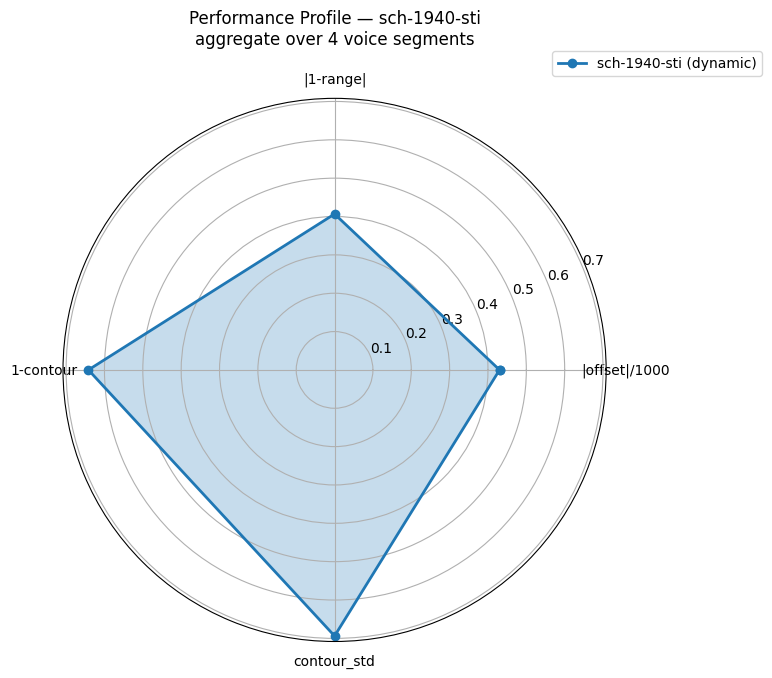

✓ Saved: /Users/gsuzuki/projects/research/sprechstimme-pitch/outputs/radar_demo.png


In [8]:
axes_norm = plotting.four_axes_normalize(
    register_offset_cent=agg['register_offset_cent'],
    range_compression=agg['range_compression'],
    contour_correlation=agg['contour_correlation_median'],
    contour_std=agg['contour_correlation_std'],
)

print('Normalized axes for radar chart:')
for key, val in axes_norm.items():
    print(f'  {key:20s}: {val:.3f}')

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(projection='polar'))
axis_keys = ['abs_offset', 'range_dev', 'contour_dev', 'contour_std']
axis_labels = ['|offset|/1000', '|1-range|', '1-contour', 'contour_std']
values = [axes_norm.get(k, 0) for k in axis_keys]
values += values[:1]
angles = np.linspace(0, 2 * np.pi, len(axis_keys), endpoint=False).tolist()
angles += angles[:1]

ax.plot(angles, values, 'o-', linewidth=2,
        label=f'{RECORDING_ID} ({perf_type})')
ax.fill(angles, values, alpha=0.25)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(axis_labels)
ax.set_title(f'Performance Profile — {RECORDING_ID}\n'
             f'aggregate over {len(per_segment_metrics)} voice segments',
             fontsize=12, pad=20)
ax.grid(True)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.savefig(EXPORT_DIR / 'radar_demo.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'✓ Saved: {EXPORT_DIR / "radar_demo.png"}')


## Summary

This notebook demonstrated the core pipeline on the Stiedry-Wagner 1940 recording:

1. **Fetch audio** -> Demucs source separation (vocals)
2. **Pitch tracking** -> pYIN on the vocals stem
3. **Per-segment loop** over the four voice segments:
    - Align with `segment_score_map.csv` (auto_align_dtw for sch-1940-sti)
    - Compute per-note pitch + reliability diagnostics
    - Flag with `is_pyin_unreliable` (voiced_low OR iqr_high OR pitch-class subharmonic)
    - `compute_three_axis_metrics` -> register / range / contour
4. **Aggregate** -> `metrics.aggregate_metrics` (median across segments + contour std)
5. **Classify** -> `metrics.classify_performance`
    -> *score-faithful* / *directed-recitation* / *dynamic*
6. **Visualise** -> four-axis radar of the per-recording aggregate

For the full paper-1 corpus (5 recordings × 4 voice segments) and the
comparative figures (PCA biplot, decision flow), see
[`02_paper_reproduction.ipynb`](02_paper_reproduction.ipynb).